In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

plt.style.use("seaborn-v0_8")

plt.rcParams["figure.figsize"]=(8,6)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Dataset_Customer_Segmentation_100_Customers.xlsx to Dataset_Customer_Segmentation_100_Customers.xlsx


In [3]:
df = pd.read_excel(
    "Dataset_Customer_Segmentation_100_Customers.xlsx"
)

df.head()

,Customer_ID,Umur,Pendapatan_Tahunan_Juta,Spending_Score,Frekuensi_Belanja_per_Bulan,Rata_Rata_Transaksi_Juta
0,C001,30,52,61,11,0.49
1,C002,23,53,66,11,0.82
2,C003,28,50,87,6,0.32
3,C004,23,59,92,10,0.32
4,C005,23,79,86,7,0.61


In [7]:
#Informasi Datasheet#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  100 non-null    object 
 1   Umur                         100 non-null    int64  
 2   Pendapatan_Tahunan_Juta      100 non-null    int64  
 3   Spending_Score               100 non-null    int64  
 4   Frekuensi_Belanja_per_Bulan  100 non-null    int64  
 5   Rata_Rata_Transaksi_Juta     100 non-null    float64
dtypes: float64(1), int64(4), object(1)
memory usage: 4.8+ KB


In [6]:
#Statistik Deskriptif#
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Umur,100.0,37.460,10.174657,20.00,30.000,36.50,45.00,60.00
Pendapatan_Tahunan_Juta,100.0,149.730,76.894373,45.00,79.000,134.50,213.50,336.00
Spending_Score,100.0,62.890,22.696903,20.00,45.750,65.00,81.25,100.00
Frekuensi_Belanja_per_Bulan,100.0,7.610,3.760225,1.00,5.000,7.00,11.00,15.00
Rata_Rata_Transaksi_Juta,100.0,2.491,1.571737,0.32,1.045,2.27,3.78,5.88


In [8]:
#Missing Value#
df.isnull().sum()

,0
Customer_ID,0
Umur,0
Pendapatan_Tahunan_Juta,0
Spending_Score,0
Frekuensi_Belanja_per_Bulan,0
Rata_Rata_Transaksi_Juta,0


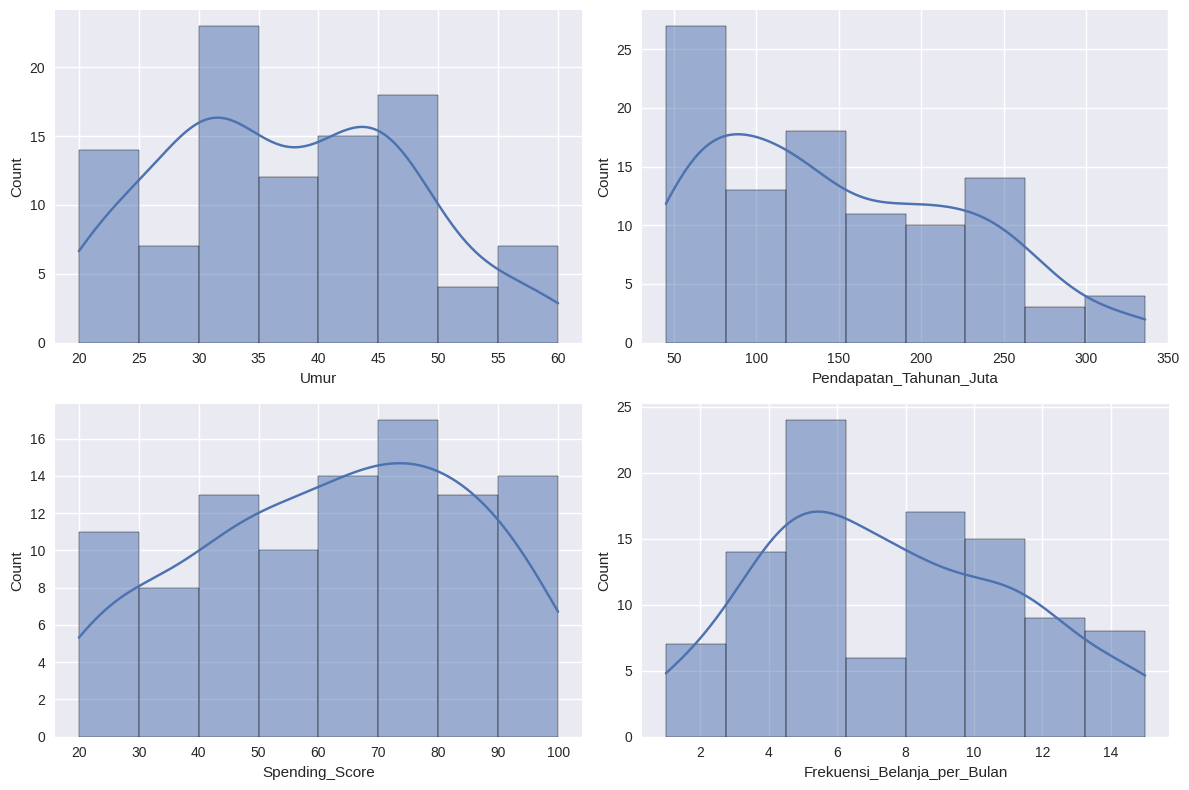

In [9]:
#Distribusi Data#
fig,ax=plt.subplots(2,2,figsize=(12,8))

sns.histplot(df["Umur"],kde=True,ax=ax[0,0])

sns.histplot(df["Pendapatan_Tahunan_Juta"],kde=True,ax=ax[0,1])

sns.histplot(df["Spending_Score"],kde=True,ax=ax[1,0])

sns.histplot(df["Frekuensi_Belanja_per_Bulan"],kde=True,ax=ax[1,1])

plt.tight_layout()

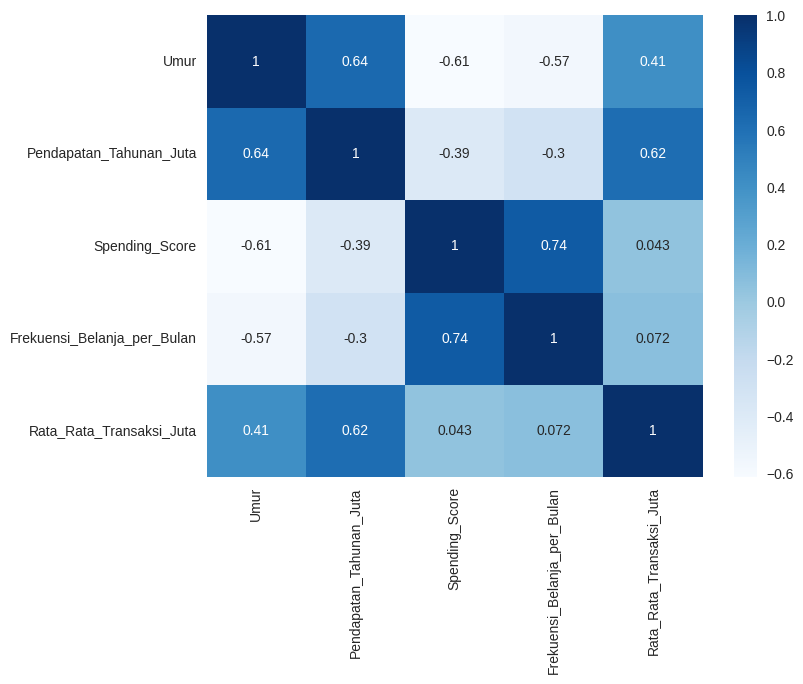

In [10]:
#Korelasi#
plt.figure(figsize=(8,6))

sns.heatmap(df.iloc[:,1:].corr(),annot=True,cmap="Blues")

plt.show()

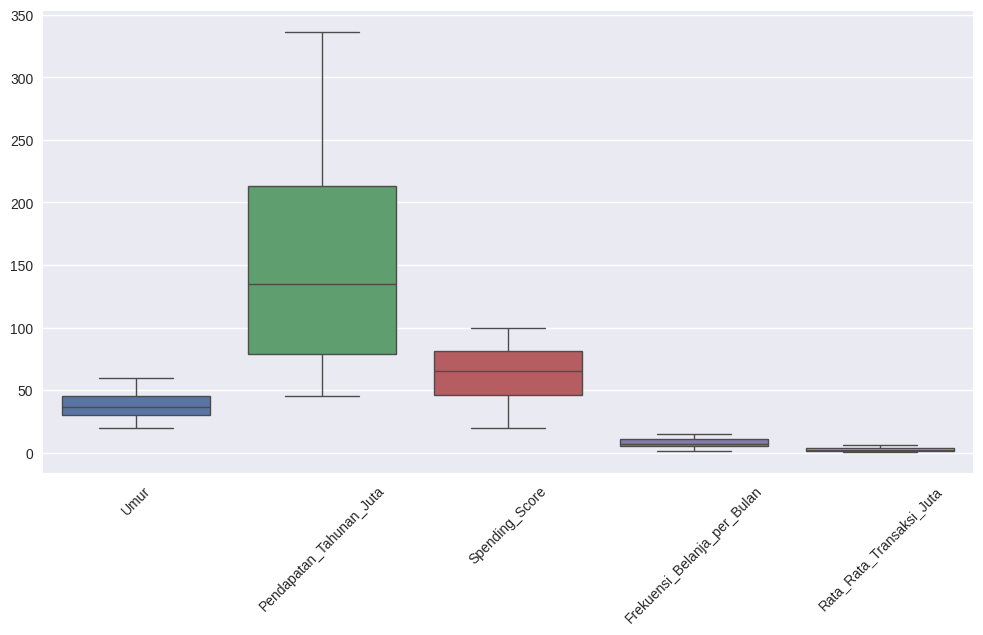

In [11]:
#Boxplot#
plt.figure(figsize=(12,6))

sns.boxplot(data=df.iloc[:,1:])

plt.xticks(rotation=45)

plt.show()

In [12]:
#Memilih Feature#
X=df.iloc[:,1:]

In [13]:
#Standardisasi#
scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

In [14]:
#Elbow Method#
wcss=[]

for i in range(2,11):

    km=KMeans(

        n_clusters=i,

        random_state=42,

        n_init=20

    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

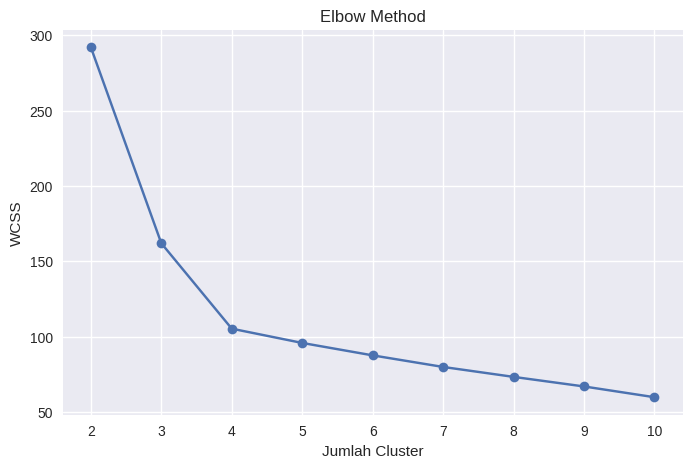

In [15]:
#Plot Elbow#
plt.figure(figsize=(8,5))

plt.plot(

    range(2,11),

    wcss,

    marker="o"

)

plt.xlabel("Jumlah Cluster")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [16]:
#Silhouette Score#
score=[]

for i in range(2,11):

    km=KMeans(n_clusters=i, random_state=42,n_init=20)

    label=km.fit_predict(X_scaled)

    score.append(silhouette_score(X_scaled,label))

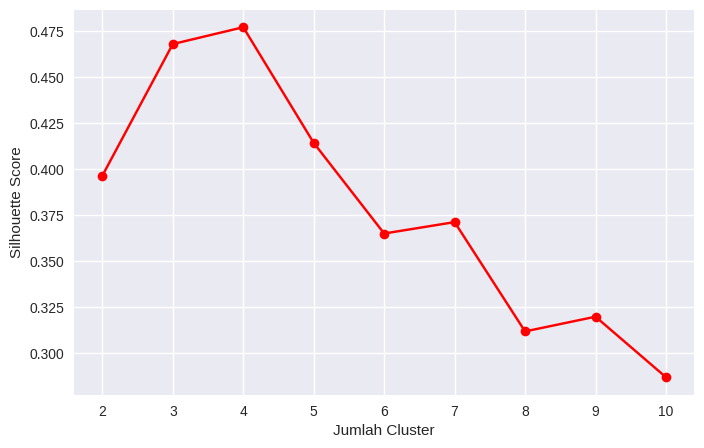

In [17]:
#Plot Silhouette#
plt.figure(figsize=(8,5))

plt.plot(

    range(2,11),

    score,

    marker="o",

    color="red"

)

plt.xlabel("Jumlah Cluster")

plt.ylabel("Silhouette Score")

plt.show()

In [18]:
#Jalankan K-Means#
k=4

kmeans=KMeans(n_clusters=k,random_state=42,n_init=20)

df["Cluster"]=kmeans.fit_predict(X_scaled)

In [19]:
#Lihat Hasil#
df.head()

,Customer_ID,Umur,Pendapatan_Tahunan_Juta,Spending_Score,Frekuensi_Belanja_per_Bulan,Rata_Rata_Transaksi_Juta,Cluster
0,C001,30,52,61,11,0.49,2
1,C002,23,53,66,11,0.82,2
2,C003,28,50,87,6,0.32,2
3,C004,23,59,92,10,0.32,2
4,C005,23,79,86,7,0.61,2


In [20]:
#Jumlah Customer per Cluster#
df.Cluster.value_counts()

,count
Cluster,
2,25
0,25
3,25
1,25


In [22]:
#Profil Cluster#
cluster_profile=df.drop("Customer_ID",axis=1).groupby("Cluster").mean()

cluster_profile

,Umur,Pendapatan_Tahunan_Juta,Spending_Score,Frekuensi_Belanja_per_Bulan,Rata_Rata_Transaksi_Juta
Cluster,,,,,
0,35.76,181.68,87.88,11.80,4.3396
1,39.72,109.88,55.88,5.88,1.7920
2,25.08,62.60,75.24,9.40,0.6624
3,49.28,244.76,32.56,3.36,3.1700


In [23]:
#PCA#
pca=PCA(n_components=2)

pca_result=pca.fit_transform(X_scaled)

df["PCA1"]=pca_result[:,0]

df["PCA2"]=pca_result[:,1]

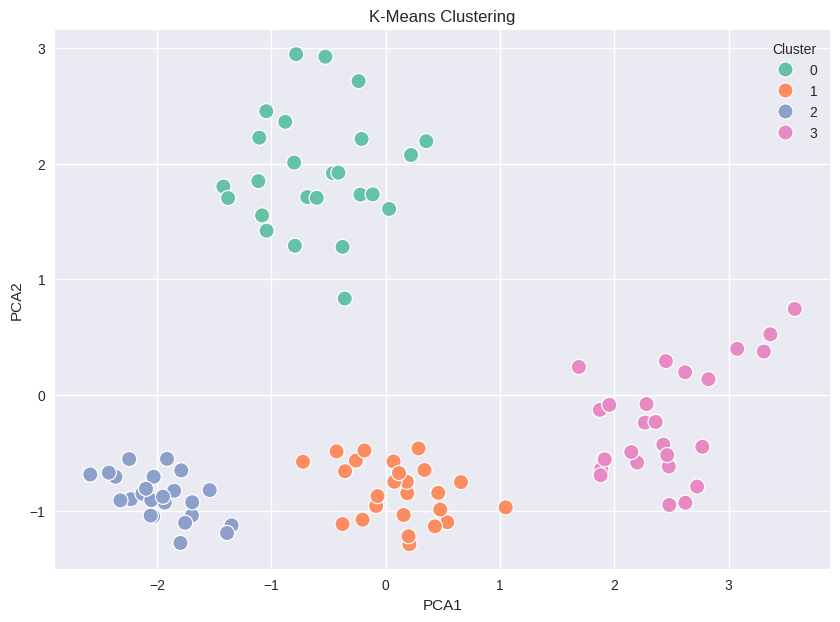

In [24]:
#Visualisasi PCA#
plt.figure(figsize=(10,7))

sns.scatterplot(data=df,x="PCA1",y="PCA2",hue="Cluster",palette="Set2",s=120)

plt.title("K-Means Clustering")

plt.show()

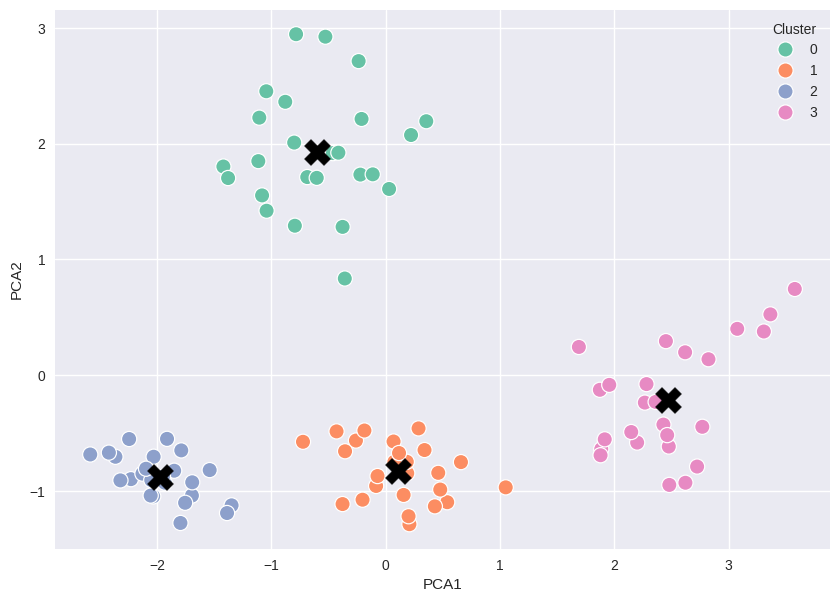

In [25]:
#Centroid PCA#
centroid=pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,7))

sns.scatterplot(data=df,x="PCA1",y="PCA2",hue="Cluster",palette="Set2",s=120)

plt.scatter(centroid[:,0],centroid[:,1],marker="X",s=350,color="black")

plt.show()

In [26]:
#Radar Chart Cluster#
from math import pi

profile=cluster_profile

labels=profile.columns

angles=np.linspace(0,2*np.pi,len(labels),endpoint=False)

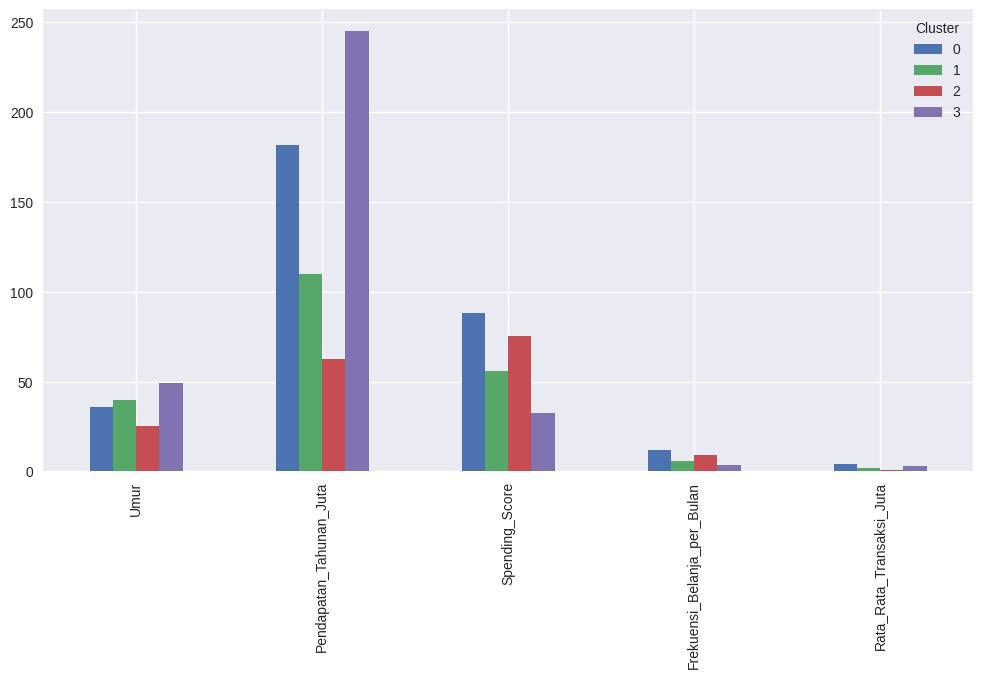

In [27]:
#Bar Chart#
cluster_profile.T.plot(kind="bar",figsize=(12,6))

plt.show()

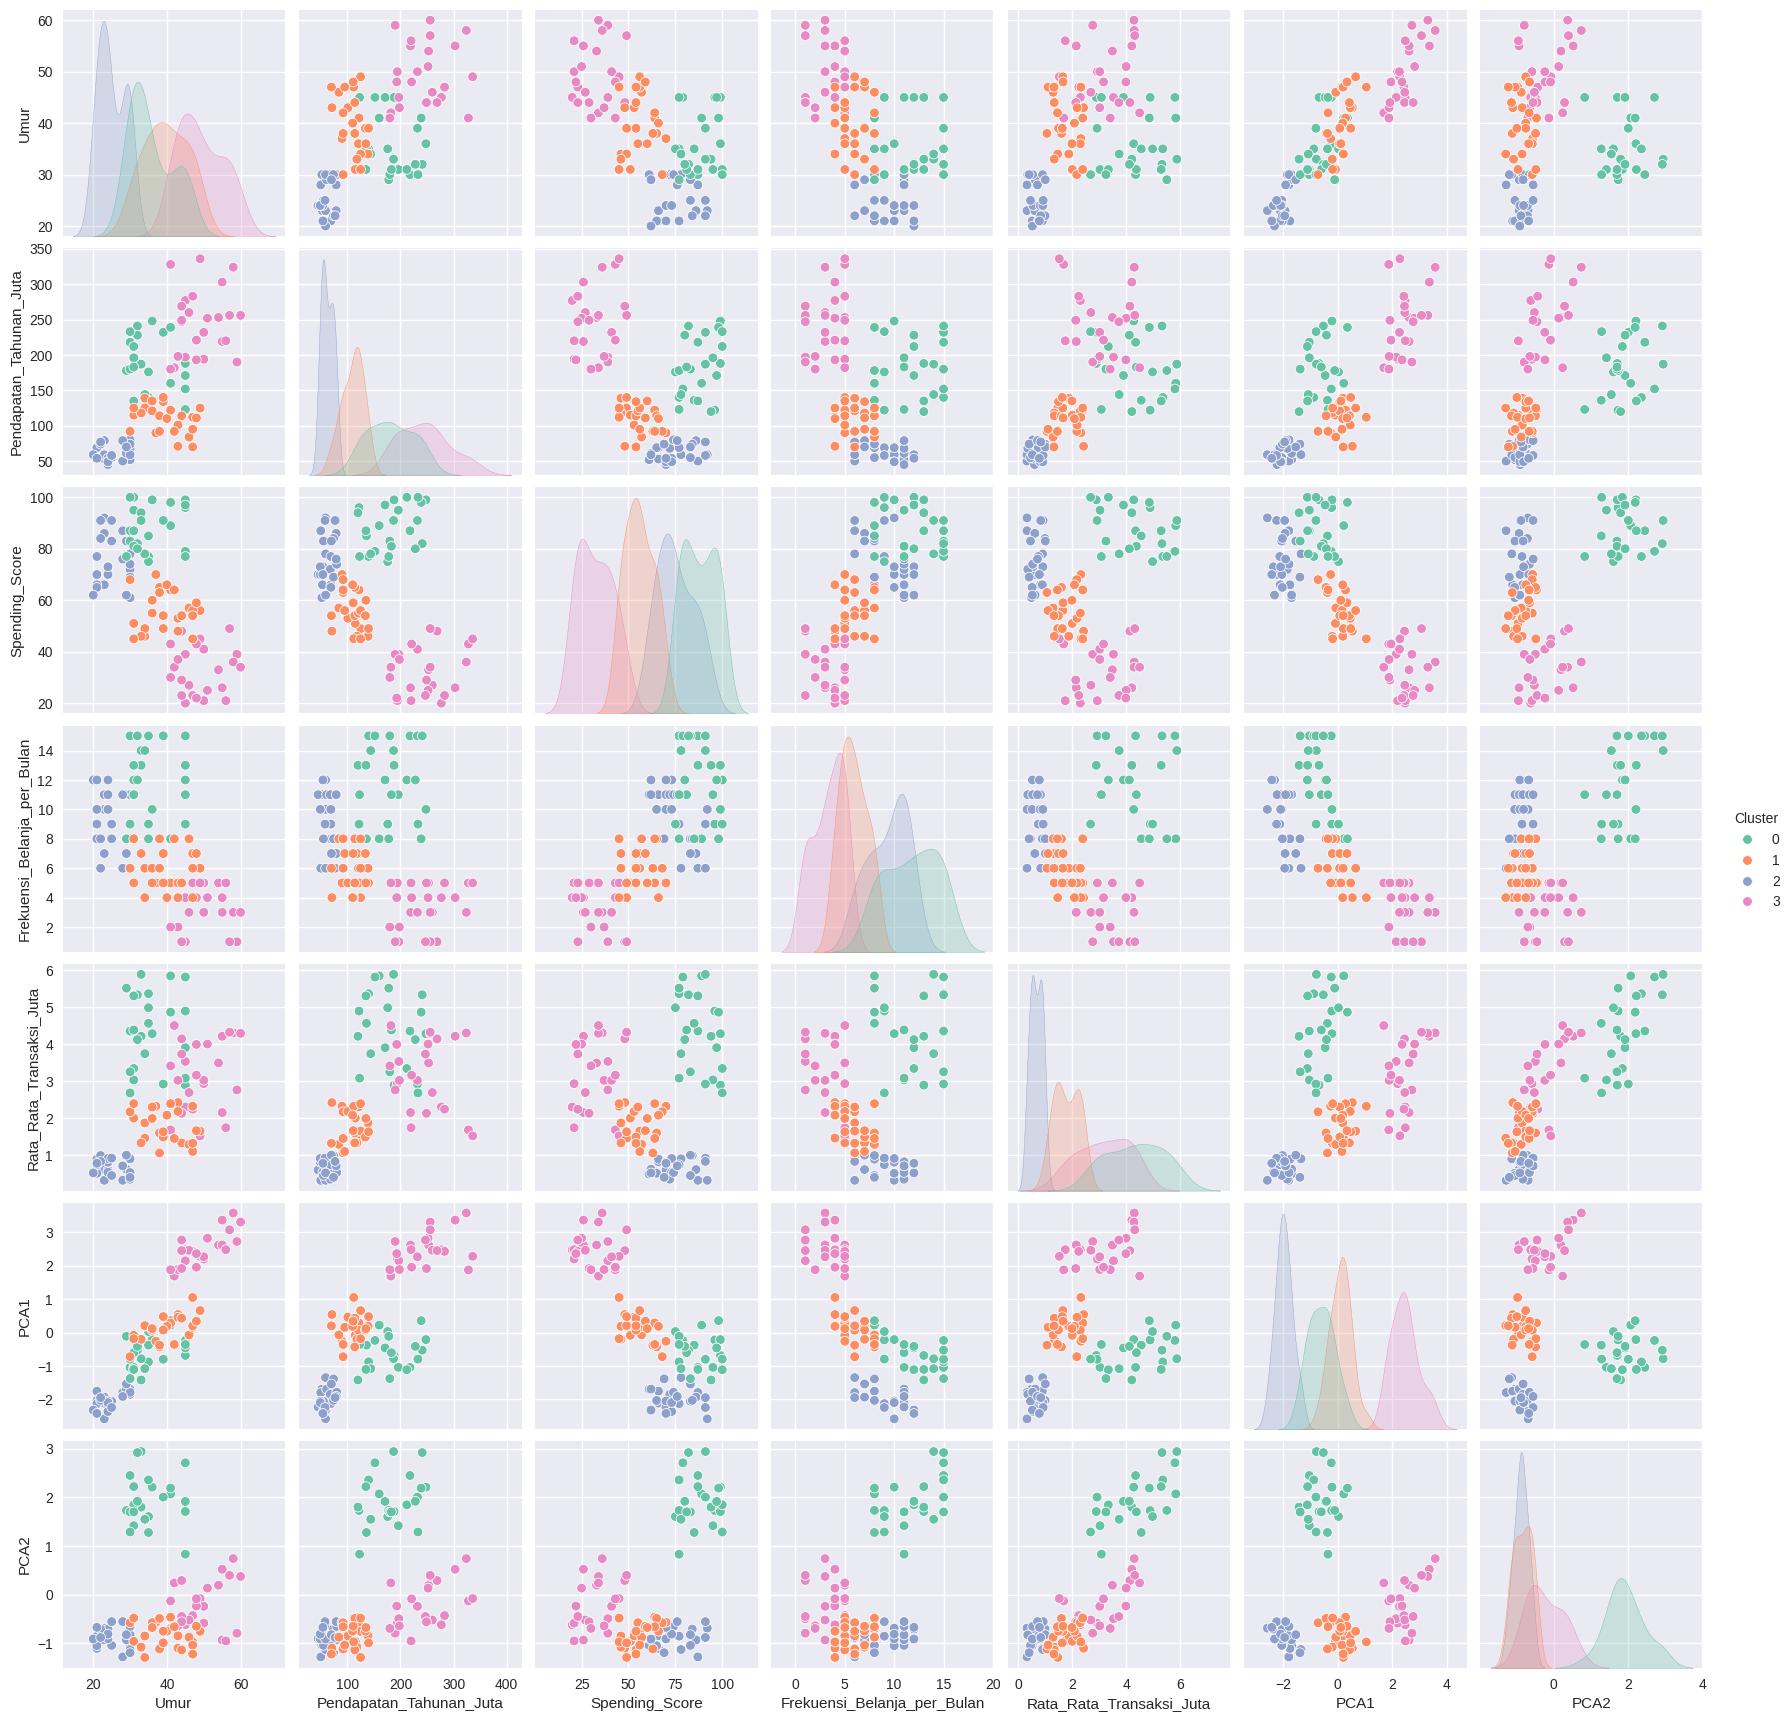

In [28]:
#Pairplot#
sns.pairplot(df,hue="Cluster",palette="Set2")